# 08. Human-in-the-Loop (사람이 개입하는 워크플로)

> 고위험 작업은 LLM이 단독으로 결정하면 안 돼요. `interrupt_before` 로 그래프를 중단해 사람의 승인을 받는 가장 기본적인 HITL 패턴을 배웁니다.

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. `interrupt_before` 파라미터로 특정 노드 실행 전에 그래프를 중단시킬 수 있어요
2. `get_state()`로 중단된 그래프의 현재 상태와 대기 중인 도구 호출을 확인할 수 있어요
3. `graph.stream(None, config)`로 중단 지점에서 그래프를 재개할 수 있어요
4. `get_state_history()`로 모든 체크포인트를 조회하고 타임 트래블(Time Travel)을 구현할 수 있어요

## 사전 지식

- 이전 노트북: `07-Memory-Checkpointer.ipynb` - InMemorySaver, thread_id, 세션 관리
- `StateGraph`, `ToolNode`, `tools_condition` 기본 개념
- `MemorySaver` 체크포인터와 `config` 설정


## Human-in-the-Loop란?

에이전트는 때로 예상치 못한 방식으로 동작하거나, 민감한 작업(파일 삭제, 이메일 전송, 결제 처리 등)을 실행하기 전에 사람의 확인이 필요할 수 있어요.

### 왜 Human-in-the-Loop가 필요한가요?

자율 주행 자동차도 긴급 상황에서는 운전자가 직접 핸들을 잡을 수 있어야 하듯이, AI 에이전트도 **중요한 결정 앞에서 사람의 확인**을 받을 수 있어야 해요. 특히 결제 처리, 이메일 발송, 데이터 삭제처럼 되돌리기 어려운 작업에서는 사람의 최종 승인이 필수적이에요.

**Human-in-the-Loop(HITL)**는 에이전트 실행 중간에 사람이 개입할 수 있는 포인트를 만드는 패턴이에요.

### 핵심 구성 요소

| 구성 요소 | 역할 | 설명 |
|-----------|------|------|
| `interrupt_before` | 중단 지점 지정 | `compile(interrupt_before=["tools"])` |
| `MemorySaver` | 상태 저장 | 중단 시점의 상태를 메모리에 보관 |
| `get_state()` | 상태 조회 | 현재 스냅샷, 다음 노드, 대기 도구 확인 |
| `stream(None, config)` | 재개 | 입력 없이 중단 지점부터 이어서 실행 |
| `get_state_history()` | 기록 조회 | 모든 체크포인트를 역순으로 조회 |
| `checkpoint_id` | 타임 트래블 | 과거 특정 시점으로 되돌아가서 재실행 |

### 전체 워크플로 다이어그램

```mermaid
flowchart TD
    A([사용자 입력<br/>User Input]) --> B[chatbot 노드<br/>LLM 응답]
    B -->|도구 호출 필요| C{interrupt_before<br/>중단 지점}
    C -->|사람이 검토| D[사람의 판단<br/>Human Review]
    D -->|승인 - Resume| E[tools 노드<br/>도구 실행]
    D -->|거부 - 수정| F[상태 수정<br/>State Update]
    E --> B
    F --> B
    B -->|도구 호출 없음| G([최종 응답<br/>Final Answer])

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef decision fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef human fill:#f8d7da,stroke:#dc3545,color:#721c24
    classDef output fill:#d4edda,stroke:#28a745,color:#155724

    class A input
    class B,E process
    class C decision
    class D,F human
    class G output
```

### 타임 트래블(Time Travel) 다이어그램

```mermaid
flowchart LR
    subgraph 체크포인트 기록
        CP0[checkpoint_0<br/>메시지 0개] --> CP1[checkpoint_1<br/>메시지 1개]
        CP1 --> CP2[checkpoint_2<br/>메시지 2개]
        CP2 --> CP3[checkpoint_3<br/>메시지 3개]
        CP3 --> CP4[checkpoint_4<br/>메시지 4개]
    end
    CP3 -->|checkpoint_id로 재실행| R[타임 트래블<br/>재실행]

    classDef storage fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085

    class CP0,CP1,CP2,CP3,CP4 storage
    class R process
```


## 환경 설정


In [24]:
# ---------------------------------------------------
# 환경 변수 로드
# ---------------------------------------------------
# .env 파일에서 OPENAI_API_KEY 등을 불러와요
from dotenv import load_dotenv

load_dotenv()


True

In [25]:
# ---------------------------------------------------
# LangSmith 추적 설정 (선택사항)
# ---------------------------------------------------
# 추적을 원하면 아래 주석을 해제하고 실행하세요
import os

# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_PROJECT"] = "LangGraph-07-HITL"


## 1. 그래프 구성 — interrupt_before 설정

HITL 그래프는 이전 노트북의 도구 사용 챗봇과 동일한 구조에요. 핵심 차이는 `compile()` 시 `interrupt_before=["tools"]`를 추가하는 것이에요.


In [26]:
# ---------------------------------------------------
# 필요한 라이브러리 임포트
# ---------------------------------------------------
# 타입 힌트
from typing import Annotated, List, Dict
from typing_extensions import TypedDict

# LangChain V1 도구 및 모델
from langchain.chat_models import init_chat_model  # V1 통합 초기화 함수
from langchain.tools import tool                   # 도구 데코레이터
from langchain.messages import HumanMessage, AIMessage

# LangGraph 핵심 컴포넌트
from langgraph.checkpoint.memory import MemorySaver  # 메모리 체크포인터
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages      # 메시지 리듀서
from langgraph.prebuilt import ToolNode, tools_condition  # 도구 노드, 라우팅 조건

# 실행 설정
from langchain_core.runnables import RunnableConfig


In [27]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [28]:
from langchain_tavily import TavilySearch

search_tool = TavilySearch()
tools = [search_tool]

In [29]:
llm = init_chat_model("openai:gpt-4o-mini")
llm_with_tools = llm.bind_tools(tools)

In [30]:
# ---------------------------------------------------
# 4단계: 그래프 노드 및 엣지 구성
# ---------------------------------------------------

# 챗봇 노드: LLM을 호출하고 응답을 반환해요
def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# 그래프 빌더 생성
graph_builder = StateGraph(State)

# 노드 추가
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=tools))  # 도구 실행 노드

# 엣지 구성
graph_builder.add_edge(START, "chatbot")             # 시작 → 챗봇
graph_builder.add_conditional_edges(                 # 챗봇 → (도구 or 종료)
    "chatbot",
    tools_condition,                                 # 도구 호출 있으면 tools, 없으면 END
)
graph_builder.add_edge("tools", "chatbot")           # 도구 → 챗봇 (결과를 LLM에 전달)

# 그래프 구조 구성 완료

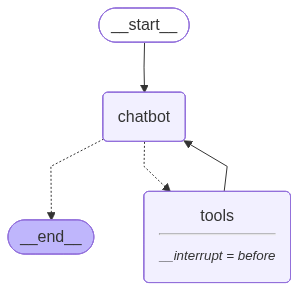

In [31]:
memory = MemorySaver()

graph = graph_builder.compile(
    checkpointer=memory,
    interrupt_before=["tools"]
)

graph

In [32]:
from IPython.display import Image, display

# TODO: 이 셀의 핵심 구현 코드를 수업 시간에 직접 작성하세요.
# 목표: 그래프 흐름: START → chatbot → tools → chatbot → ... → END
# 위 마크다운 설명과 힌트를 참고해 필요한 타입, 함수, 그래프 구성, 실행 코드를 완성하세요.


## 2. 그래프 실행 및 Interrupt 확인

이제 그래프를 실행해서 `interrupt_before`가 어떻게 동작하는지 직접 확인해볼게요.

도구 호출이 필요한 질문을 입력하면, `tools` 노드 실행 직전에 그래프가 일시 중단되는 걸 볼 수 있어요.


> 🤔 **자주 묻는 질문**: "`interrupt_before=['tools']`니까 모든 도구 호출 전에 멈추는 거죠?"
>
> 네, 맞아요. 이 설정에서는 LLM이 도구 호출(tool_call)을 결정해서 `tools` 노드로 라우팅되는 **모든 턴마다** `tools` 노드 실행 직전에 그래프가 일시 중단돼요. 다만 몇 가지 짚어둘 점이 있어요.
>
> - **노드 단위 중단**이지 도구 단위 중단이 아니에요. 한 번의 LLM 응답에 여러 `tool_call`이 들어 있어도 `tools` 노드는 한 번 실행되므로, 중단도 한 번이고 재개하면 그 안의 도구들이 한꺼번에 실행돼요. "도구별로 따로따로 승인"되는 게 아니에요.
> - LLM이 도구 호출을 안 하면 `tools_condition`이 바로 `END`로 보내므로 중단 자체가 일어나지 않아요.
> - "고위험 도구만 멈추기" 같은 **선택적 중단**은 `interrupt_before`로는 불가능해요. 위쪽 안내처럼 `langgraph.types.interrupt()` + `Command(resume=...)` 패턴(`06_Middleware/02-Human-In-The-Loop-V1.ipynb`)으로 가야 해요.


In [33]:
question = "Claude 관련 최신 업데이트 소식을 한글로 알려주세요."

initial_input = State(messages=[("user", question)])

config = RunnableConfig(
    recursion_limit=10,
    configurable={"thread_id": "thread-1"}
)

for chunk in graph.stream(initial_input, config, stream_mode='values'):
    if "messages" in chunk and chunk["messages"]:
        last_msg = chunk["messages"][-1]
        last_msg.pretty_print()

================================ Human Message =================================

Claude 관련 최신 업데이트 소식을 한글로 알려주세요.
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_Oi4Y5Dv43dIOBBA4nizb63QD)
 Call ID: call_Oi4Y5Dv43dIOBBA4nizb63QD
  Args:
    query: Claude AI 최신 뉴스
    time_range: week
    topic: news


## 3. 현재 상태 확인 — get_state()

그래프가 중단되었을 때 `get_state()`로 현재 상태를 조회할 수 있어요.

> 🔑 **핵심 개념**: `snapshot.next`는 다음에 실행될 노드의 이름을 담고 있어요. 그래프가 정상 종료되면 `snapshot.next`는 빈 튜플 `()`이에요. `('tools',)`처럼 값이 있으면 아직 실행 중이라는 뜻이에요.


In [34]:
snapshot = graph.get_state(config)

print(snapshot.values)
print(snapshot.next)

{'messages': [HumanMessage(content='Claude 관련 최신 업데이트 소식을 한글로 알려주세요.', additional_kwargs={}, response_metadata={}, id='aa38bcae-addb-48e3-96af-b8706b85b2df'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 1199, 'total_tokens': 1227, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_073fa0c255', 'id': 'chatcmpl-DffhYd2Lq7zTlxNnTgPIbJZWVtSOa', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e2a2e-07a1-7a80-9638-66802f47dc10-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'Claude AI 최신 뉴스', 'time_range': 'week', 'topic': 'news'}, 'id': 'call_Oi4Y5Dv43dIOBBA4nizb63QD', 'type': 'tool_call'}], invalid_t

In [35]:
# ---------------------------------------------------
# 대기 중인 도구 호출 정보 확인
# ---------------------------------------------------
# snapshot.values["messages"][-1]: 마지막 메시지 (AIMessage with tool_calls)
last_message = snapshot.values["messages"][-1]

print("마지막 메시지 타입:", last_message.type)
print()

# tool_calls: 실행을 기다리고 있는 도구 호출 목록
if hasattr(last_message, "tool_calls") and last_message.tool_calls:
    # 대기 중인 도구 호출:
    for i, tc in enumerate(last_message.tool_calls):
        print(f"  [{i}] 도구 이름: {tc['name']}")
        print(f"       인자: {tc['args']}")
        print(f"       ID: {tc['id']}")
else:
    # 대기 중인 도구 호출 없음
    pass

마지막 메시지 타입: ai

  [0] 도구 이름: tavily_search
       인자: {'query': 'Claude AI 최신 뉴스', 'time_range': 'week', 'topic': 'news'}
       ID: call_Oi4Y5Dv43dIOBBA4nizb63QD


## 4. 그래프 재개 — Resume with None

사람이 검토 후 실행을 승인하면, 그래프를 재개할 수 있어요.

### `None` 입력 vs 새 입력의 차이

| 입력 | 동작 | 사용 시점 |
|------|------|----------|
| `graph.stream(None, config)` | 중단 지점에서 **그대로 재개** | 승인 후 원래 도구를 실행할 때 |
| `graph.stream({"messages": [...]}, config)` | 새 메시지를 추가하고 재실행 | 사용자가 질문을 수정할 때 | 사람이 승인하면 `stream(None, config)`를 호출하고, 거부하면 상태를 수정하거나 다른 처리를 진행해요.


In [36]:
for chunk in graph.stream(None, config, stream_mode="values"):
    if "messages" in chunk and chunk["messages"]:
        last_msg = chunk["messages"][-1]
        last_msg.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_Oi4Y5Dv43dIOBBA4nizb63QD)
 Call ID: call_Oi4Y5Dv43dIOBBA4nizb63QD
  Args:
    query: Claude AI 최신 뉴스
    time_range: week
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "Claude AI 최신 뉴스", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://news.sap.com/2026/05/sap-anthropic-to-bring-claude-sap-business-ai-platform/", "title": "SAP and Anthropic Plan to Bring Claude to SAP Business AI Platform - SAP News Center", "score": 0.7447496, "published_date": "Tue, 12 May 2026 12:33:00 GMT", "content": "# SAP and Anthropic Plan to Bring Claude to SAP Business AI Platform. SAP and Anthropic today announced plans to expand their collaboration to deliver advanced AI solutions to enterprise customers, making Claude, Anthropic’s AI model, a primary reasoning and agentic ca

In [42]:
# ---------------------------------------------------
# 재개 후 상태 확인
# ---------------------------------------------------
# 정상 종료되면 snapshot.next가 빈 튜플 () 이어야 해요
final_snapshot = graph.get_state(config)

print("실행 완료 후 snapshot.next:", final_snapshot.next)
print("최종 메시지 수:", len(final_snapshot.values["messages"]))

실행 완료 후 snapshot.next: ()
최종 메시지 수: 4


## 5. 상태 기록 조회 — get_state_history()

LangGraph는 그래프 실행의 모든 단계에서 체크포인트를 저장해요. `get_state_history()`로 전체 실행 기록을 조회할 수 있어요.


In [43]:
# ---------------------------------------------------
# 전체 상태 기록 조회
# ---------------------------------------------------
# get_state_history(): 현재까지의 모든 체크포인트를 역순으로 반환해요
# 전체 상태 기록 (최신 → 오래된 순):
# ============================================================

for i, state in enumerate(graph.get_state_history(config)):
    msg_count = len(state.values["messages"])
    next_node = state.next
    checkpoint_id = state.config["configurable"].get("checkpoint_id", "N/A")
    
    print(f"[체크포인트 {i}]")
    print(f"  메시지 수: {msg_count}")
    print(f"  다음 노드: {next_node}")
    print(f"  checkpoint_id: {checkpoint_id[:20]}...")  # 일부만 출력
    # ----------------------------------------

[체크포인트 0]
  메시지 수: 4
  다음 노드: ()
  checkpoint_id: 1f15021c-3bfa-691e-8...
[체크포인트 1]
  메시지 수: 3
  다음 노드: ('chatbot',)
  checkpoint_id: 1f15021b-ad64-6574-8...
[체크포인트 2]
  메시지 수: 2
  다음 노드: ('tools',)
  checkpoint_id: 1f15021b-a476-6566-8...
[체크포인트 3]
  메시지 수: 1
  다음 노드: ('chatbot',)
  checkpoint_id: 1f15021b-98b2-69be-8...
[체크포인트 4]
  메시지 수: 0
  다음 노드: ('__start__',)
  checkpoint_id: 1f15021b-98b0-67c2-b...


In [47]:
# 특정 체크포인트 선택
# 메시지가 3개인 체크포인트 찾기

to_reply = None

for state in graph.get_state_history(config):
    msg_count = len(state.values["messages"])
    print(msg_count)

    if msg_count == 3:
        to_reply = state
        break

print(to_reply.values["messages"])
print(to_reply.next)
print(to_reply.config)

4
3
[HumanMessage(content='Claude 관련 최신 업데이트 소식을 한글로 알려주세요.', additional_kwargs={}, response_metadata={}, id='aa38bcae-addb-48e3-96af-b8706b85b2df'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 1199, 'total_tokens': 1227, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_073fa0c255', 'id': 'chatcmpl-DffhYd2Lq7zTlxNnTgPIbJZWVtSOa', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e2a2e-07a1-7a80-9638-66802f47dc10-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'Claude AI 최신 뉴스', 'time_range': 'week', 'topic': 'news'}, 'id': 'call_Oi4Y5Dv43dIOBBA4nizb63QD', 'type': 'tool_call'}], invalid_tool_calls

## 6. 타임 트래블 — checkpoint_id로 과거 시점 재실행

선택한 체크포인트의 `config`를 사용하면, 그 시점부터 그래프를 다시 실행할 수 있어요.


In [49]:
for chunk in graph.stream(None, to_reply.config, stream_mode="values"):
    if "messages" in chunk and chunk["messages"]:
            last_msg = chunk["messages"][-1]
            last_msg.pretty_print()

================================= Tool Message =================================
Name: tavily_search

{"query": "Claude AI 최신 뉴스", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://news.sap.com/2026/05/sap-anthropic-to-bring-claude-sap-business-ai-platform/", "title": "SAP and Anthropic Plan to Bring Claude to SAP Business AI Platform - SAP News Center", "score": 0.7447496, "published_date": "Tue, 12 May 2026 12:33:00 GMT", "content": "# SAP and Anthropic Plan to Bring Claude to SAP Business AI Platform. SAP and Anthropic today announced plans to expand their collaboration to deliver advanced AI solutions to enterprise customers, making Claude, Anthropic’s AI model, a primary reasoning and agentic capability embedded across SAP’s AI-enabled solution portfolio, powered by Joule and Joule agents. Unveiled today at SAP Sapphire, Anthropic and SAP will collaborate to embed Claude’s agentic capabilities into the newly announced SAP Business AI Platform 

## 7. 실습 — 나만의 HITL 워크플로 구성

아래 TODO 블록을 완성해서 직접 Human-in-the-Loop 워크플로를 실험해보세요!


In [41]:
# ============================================================
# TODO: 새로운 thread_id로 HITL 워크플로를 처음부터 실행해보세요
#
# 힌트:
#   1. config에서 thread_id를 다른 값으로 변경하세요 (예: "thread-2")
#   2. 도구 호출이 필요한 새 질문을 작성하세요
#   3. graph.stream()으로 실행 → snapshot = graph.get_state()로 중단 확인
#   4. snapshot.next가 ('tools',)임을 확인한 후, graph.stream(None, config)로 재개
#
# 예상 결과:
#   - 첫 번째 stream 후: snapshot.next == ('tools',)
#   - None으로 재개 후: 도구 실행 결과와 최종 답변이 출력되어요
# ============================================================

# 1. 새 config 설정


# 3. 첫 번째 실행 (interrupt_before 작동 확인)
# 첫 번째 실행:
# TODO: graph.stream()으로 new_input, new_config 실행

# 4. 상태 확인
# TODO: new_snapshot = graph.get_state(new_config)
# TODO: new_snapshot.next 출력

# 5. 재개
# 재개:
# TODO: graph.stream(None, new_config)로 재개


## 핵심 요약

이 노트북에서 다음 내용을 배웠어요:

| 기능 | 코드 | 설명 |
|------|------|------|
| **중단 지점 설정** | `compile(interrupt_before=["tools"])` | 지정 노드 실행 전 그래프 일시 중단 |
| **상태 조회** | `graph.get_state(config)` | 현재 스냅샷, `next` 노드, 대기 도구 확인 |
| **재개** | `graph.stream(None, config)` | 입력 없이 중단 지점부터 이어서 실행 |
| **기록 조회** | `graph.get_state_history(config)` | 모든 체크포인트를 역순으로 조회 |
| **타임 트래블** | `graph.stream(None, to_replay.config)` | 특정 `checkpoint_id`로 과거 시점 재실행 |

- **`interrupt_before`**: `compile()` 시 설정하며, 반드시 `checkpointer`와 함께 사용해야 해요
- **`snapshot.next`**: `('tools',)`이면 중단 중, `()`이면 실행 완료를 의미해요
- **`snapshot.values["messages"][-1].tool_calls`**: 대기 중인 도구 호출 정보를 담고 있어요
- **타임 트래블**: `checkpoint_id`를 활용해 과거 상태로 되돌아가서 다른 방향으로 재실행할 수 있어요


## 다음 노트북 예고

다음 `09-State-Management.ipynb`에서는 **Custom State, State History, 롤백**을 배워요. 단순한 메시지 목록을 넘어서 복잡한 상태를 정의하고, `update_state()`로 상태를 직접 수정하는 방법과 체크포인트를 활용한 롤백 전략을 다뤄요.
